<a href="https://colab.research.google.com/github/sushmita-bit-bot/Diabetes-detection/blob/main/Copy_of_dip_proj.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install opencv-python
from google.colab import files
uploaded = files.upload()

Saving dip_image2.jpg to dip_image2.jpg


Object Count: 10


(np.float64(-0.5), np.float64(286.5), np.float64(219.5), np.float64(-0.5))

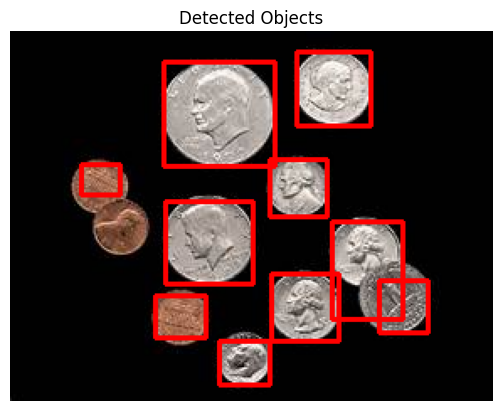

In [ ]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Read image
img = cv2.imread('dip_image2.jpg') # Changed to use an available image file
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

# Noise removal
blur = cv2.GaussianBlur(gray, (5,5), 0)

# Thresholding
_, thresh = cv2.threshold(blur, 127, 255, cv2.THRESH_BINARY)

# Morphological operations
kernel = np.ones((3,3), np.uint8)
thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)

# Find contours
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Draw bounding boxes
count = 0
for cnt in contours:
    area = cv2.contourArea(cnt)
    if area > 100:
        x, y, w, h = cv2.boundingRect(cnt)
        cv2.rectangle(img, (x,y), (x+w,y+h), (255,0,0), 2)
        count += 1

print("Object Count:", count)

plt.imshow(img)
plt.title("Detected Objects")
plt.axis('off')